## Imports

In [1]:
import math, random
import torch, torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import numpy as np

## Variables

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 32
EMBD_DIM = 64
ATTENTION_HEADS = 4
BATCH_SIZE = 12
EPOCHS = 50
LR = 3e-4
TEMPERATURE = 0.07

## Synthetic dataset properties

In [3]:
colors = ['red', 'green','blue','yellow','purple','orange','pink','brown','grey']
shapes = ['square','circle','triangle']
positions = ['top','bottom','left','center','right','top-left','top-right', 'bottom-left','bottom-right']

## Drawing image shapes

In [4]:
def draw_sample(color, shape, position, img_size = IMG_SIZE):
    img = Image.new('RGB',(img_size,img_size),'white')
    draw = ImageDraw.Draw(img)
    margin = 6
    h = w = img_size - 2*margin
    # calculate x-coordinates
    if "left" in position:
        x0 = margin
        x1 = margin + w//2
    elif "top-left" in position:
        x0 = margin
        x1 = margin + w//2
    elif "bottom-left" in position:
        x0 = margin
        x1 = margin + w//2
    elif "right" in position:
        x0 = margin + w//2
        x1 = img_size-margin
    elif "top-right" in position:
        x0 = margin + w//2
        x1 = img_size-margin
    elif "bottom-right" in position:
        x0 = margin + w//2
        x1 = img_size-margin
    else:  # center
        x0 = margin+w//4
        x1 = margin + 3*w//4
    # calculate y coordinates
    if ("top" in position)or("top-left" in position) or ("top-right" in position):
        y0 = margin
        y1 = margin+h//2
    elif ("bottom" in position)or("bottom-right" in position)or("bottom-left" in position):
        y0 = margin+h//2
        y1 = img_size-margin
    else: # center
        y0 = margin + h//4
        y1 = margin + 3* h//4

    if shape == "square":
        draw.rectangle([x0,y0,x1,y1],fill=color,outline="black")
    elif shape == "circle":
        draw.ellipse([x0,y0,x1,y1],fill=color,outline="black")
    elif shape=="triangle": # trianle
        draw.polygon([(x0+(x1-x0)//2,y0),(x0,y1),(x1,y1)],fill=color,outline="black")

    return img

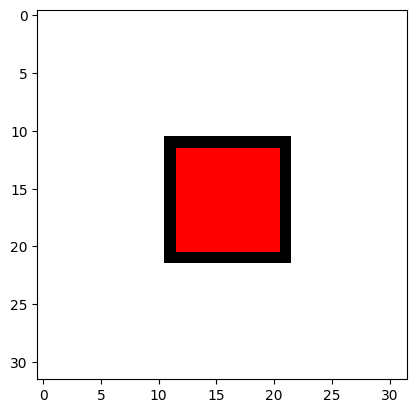

In [5]:
img = draw_sample("red","square","center")
plt.imshow(img)
plt.show()

## Class for building dataset

In [6]:
class ShapesDataset(Dataset):
    def __init__(self):
        self.images = []
        self.captions = []

        # generate all possible triplets
        for c in colors:
            for s in shapes:
                for p in positions:
                    img = draw_sample(c,s,p)
                    cap = f"{c} {s} {p}"
                    self.images.append(torch.from_numpy(np.asarray(img)).permute(2,0,1).float()/255.0)
                    self.captions.append(cap)
        self.vocab, self.word2index = self.build_vocab(self.captions)
        
    def build_vocab(self, texts):
        words = sorted({w for t in texts for w in t.split()})
        vocab = ['[CLS]']+words
        w2i = {w:i for i,w in enumerate(vocab)}
        return vocab, w2i

    def encode_text(self, text):
        tokens = [self.word2index['[CLS]']]+[self.word2index[w] for w in text.split()]
        return torch.tensor(tokens, dtype = torch.long)
        
    def __len__(self):
        return len(self.captions)
        
    def __getitem__(self, idx):
        return self.images[idx], self.encode_text(self.captions[idx]), self.captions[idx]

    

## Create full dataset

In [7]:
full_ds = ShapesDataset()

/tmp/ipykernel_46648/2246006513.py:12: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  self.images.append(torch.from_numpy(np.asarray(img)).permute(2,0,1).float()/255.0)


In [8]:
VOCAB_SIZE = len(full_ds.vocab)
print(VOCAB_SIZE)

22


## Train-val dataset creation

In [9]:
train_size = int(0.8*len(full_ds))
val_size = len(full_ds)-train_size
train_ds, val_ds = torch.utils.data.random_split(full_ds,[train_size, val_size])

## Dataloader

In [10]:
train_loader = DataLoader(train_ds,BATCH_SIZE,shuffle=True)
val_loader = DataLoader(val_ds,BATCH_SIZE,shuffle=False)

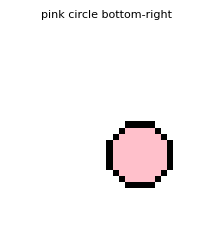

In [11]:
imgs, encoded_caps,_ = next(iter(train_loader))
idx = random.randint(0,len(imgs)-1)
img = (imgs[idx].permute(1,2,0).numpy()*255).astype(np.uint8)
# decode caption
caption_tokens = encoded_caps[idx].tolist()
caption = " ".join([full_ds.vocab[token] for token in caption_tokens if token in range(len(full_ds.vocab))])
caption = caption.replace('[CLS] ',"")

plt.figure(figsize=(2.5,2.5))
plt.imshow(img)
plt.title(caption,fontsize=8)
plt.axis("off")
plt.show()

## Image Encoder

In [12]:
class ImageEncoder(nn.Module):
    def __init__(self,emd_dim= EMBD_DIM):
        super().__init__()
        self.convolution = nn.Sequential(
            nn.Conv2d(3,32,3,2,1),
            nn.ReLU(),
            nn.Conv2d(32,64,3,2,1),
            nn.ReLU(),
            nn.Conv2d(64,128,3,2,1),
            nn.ReLU(),
            nn.Conv2d(128,256,3,2,1),
            nn.ReLU(),
        )
        self.projection = nn.Linear(256,emd_dim)
        self.layer_norm1 = nn.LayerNorm(emd_dim)

    def forward(self, x):
        x = self.convolution(x) # (N,C,H,W)
        x = x.mean(dim=[2,3])  # Global average pool
        x = self.projection(x)
        x = F.normalize(self.layer_norm1(x),dim=-1) # unit norm embedding
        return x

## Text Encode

In [13]:
class TextEncoder(nn.Module):
    def __init__(self,embed_dim= EMBD_DIM, num_heads = ATTENTION_HEADS, vocab_size = VOCAB_SIZE, context_window = 4):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, embed_dim) # convert each token like "red" into 64-dimensional vector
        self.position_embedding = nn.Embedding(context_window, embed_dim)
        self.mha = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.projection = nn.Linear(embed_dim,embed_dim)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, toks):
        N,L = toks.shape # Eg: (12,4) =(Batch means number of captions, number of tokens per caption like "[CLS, red, square, center]")
        position_emb_ids = torch.arange(L,device=toks.device).unsqueeze(0).expand(N,L)
        position_embedding_vectors = self.position_embedding(position_emb_ids)
        token_embedding_vectors = self.token_embedding(toks)
        x = token_embedding_vectors + position_embedding_vectors
        x = self.mha(x,x,x)[0]
        x = x[:,0] # take only '[CLS]' embedding
        x = self.projection(x)
        x = F.normalize(self.norm(x), dim=-1)

        return x

## CLIP Loss

In [14]:
def clip_loss(img_embd, text_embd, temperature=TEMPERATURE):
    logits = img_embd @ text_embd.T /temperature
    targets = torch.arange(img_embd.size(0), device = img_embd.device)
    loss_i = F.cross_entropy(logits, targets)
    loss_t = F.cross_entropy(logits.T, targets)
    return ((loss_i+loss_t)/2.0)

## Model, data, optimizer

In [15]:
img_enc = ImageEncoder().to(DEVICE)
txt_enc = TextEncoder().to(DEVICE)
optimizer = torch.optim.Adam(
    list(img_enc.parameters()) + list(txt_enc.parameters()),
    lr = LR
)

## Training loop

In [16]:

best_val = float('inf')
for epoch in range(1, EPOCHS+1):
    img_enc.train(),txt_enc.train()
    total = 0.0
    for imgs, toks, _ in train_loader:
        imgs, toks = imgs.to(DEVICE), toks.to(DEVICE)
        optimizer.zero_grad()
        ie = img_enc(imgs)
        te = txt_enc(toks)
        loss = clip_loss(ie,te)
        loss.backward()
        optimizer.step()
        total += loss.item()*imgs.size(0)
    train_loss = total / len(train_loader.dataset)

    # quick val
    img_enc.eval(),txt_enc.eval()
    with torch.no_grad():
        v_total,n = 0.0, 0
        for imgs, toks, _ in val_loader:
            imgs, toks = imgs.to(DEVICE), toks.to(DEVICE)
            v_total += clip_loss(img_enc(imgs),txt_enc(toks)).item()*imgs.size(0)
            n += imgs.size(0)
        val_loss = v_total/n
        
    print(f"Epoch {epoch:02d} | train Loss : {train_loss:.4f}  | val loss : {val_loss:.4f}")
    best_val = min(best_val,val_loss)

Epoch 01 | train Loss : 2.4859  | val loss : 2.3989
Epoch 02 | train Loss : 2.3060  | val loss : 1.9603
Epoch 03 | train Loss : 1.1576  | val loss : 1.2405
Epoch 04 | train Loss : 0.8070  | val loss : 0.6976
Epoch 05 | train Loss : 0.4570  | val loss : 0.6275
Epoch 06 | train Loss : 0.3694  | val loss : 0.2556
Epoch 07 | train Loss : 0.2001  | val loss : 0.1891
Epoch 08 | train Loss : 0.1800  | val loss : 0.3070
Epoch 09 | train Loss : 0.1580  | val loss : 0.1816
Epoch 10 | train Loss : 0.1275  | val loss : 0.1468
Epoch 11 | train Loss : 0.1570  | val loss : 0.1721
Epoch 12 | train Loss : 0.1437  | val loss : 0.2112
Epoch 13 | train Loss : 0.1445  | val loss : 0.1693
Epoch 14 | train Loss : 0.1639  | val loss : 0.2128
Epoch 15 | train Loss : 0.1399  | val loss : 0.1540
Epoch 16 | train Loss : 0.1426  | val loss : 0.1514
Epoch 17 | train Loss : 0.1041  | val loss : 0.1002
Epoch 18 | train Loss : 0.0633  | val loss : 0.0887
Epoch 19 | train Loss : 0.0624  | val loss : 0.0768
Epoch 20 | t

## Evaluate model

In [17]:
# Build text bank for retrieval on val set
img_enc.eval(), txt_enc.eval()
with torch.no_grad():
    val_imgs, val_toks, val_caps = [],[],[]
    for imgs,toks,caps in val_loader:
        val_imgs.append(imgs); val_toks.append(toks); val_caps.extend(caps)
    val_imgs = torch.cat(val_imgs).to(DEVICE)
    val_toks = torch.cat(val_toks).to(DEVICE)
    img_embd = img_enc(val_imgs)
    txt_embd = txt_enc(val_toks)

In [18]:
def show_image(img, title = None):
    plt.figure(figsize=(4,4))
    plt.imshow(img.permute(1,2,0))
    if title is not None:
        plt.title(title, fontsize=16)
    plt.axis("off")
    plt.show()

In [19]:
# Retrieval helper function for images from text
def topk_text_for_images(k = 3, idxs = None):
    if idxs is None : idxs = np.random.choice(len(val_caps), size=1,replace=False)
    sims = img_embd @ txt_embd.T
    for i in idxs:
        best = sims[i].topk(k).indices.tolist()
        print(f"\nImage {i} best captions:")
        for j in best:
            print ("  -", val_caps[j])
        show_image(val_imgs[i].cpu())


Image 46 best captions:
  - grey triangle bottom


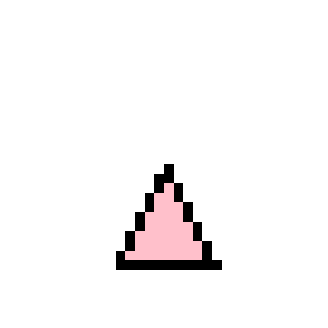

In [20]:
topk_text_for_images(k=1)

In [21]:
# Retrieval helper function for images from text
def topk_images_for_text(k = 3, idxs = None):
    if idxs is None: idxs = np.random.choice(len(val_imgs), size = 1, replace = False)
    sims = txt_embd @ img_embd.T
    for i in idxs:
        best = sims[i].topk(k).indices.tolist()
        print(f"\nText '{val_caps[i]}' best images:")
        for j in best:
            print ("  -", val_caps[j])
            show_image(val_imgs[j].cpu(), title = f"Match {val_caps[j]}")


Text 'blue circle top-left' best images:
  - blue circle top-left


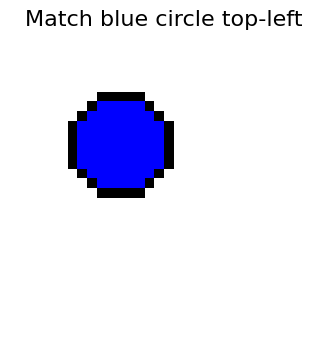

In [36]:
topk_images_for_text(k=1)